## Setup

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Helvetica'
plt.rcParams['font.size'] = 12
plt.rcParams['figure.figsize'] = [10, 6]

# Set pandas display options to show all columns for .head command
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', None)       # Auto-detect the display width
pd.set_option('display.max_colwidth', None)  # Show full content of each column

## 1. Motivation
> What is your dataset?
> Why did you choose this/these particular dataset(s)?
    
We combined multiple dataset since using only one was not possible to convey the whole story we chose. Our datasets are:
1. Results from a 2021 study on the Global Burden of Disease (GBD) https://vizhub.healthdata.org/gbd-results?params=gbd-api-2021-permalink/e536e88427a28a4e136289ad19ec6c0b.
    - We chose this dataset because it containes number of deaths and causes of death gloablly. It allows us to divide by country, sex and filter by causes that are alcohol related.
2. The Russian Fertility and Mortality database (RusFMD) of the Centre of Demographic Research of the New Economic School (CDR NES) (https://www.nes.ru/demogr-fermort-data?lang=en) 
    - Contains detailed mortality data about with groupings by cause of death, region, year, age, gender and urban/rural areas
3. Alcohol, recorded per capita (15+) consumption (in litres of pure alcohol), by beverage type, WHO (https://www.who.int/data/gho/data/indicators/indicator-details/GHO/alcohol-recorded-per-capita-(15-)-consumption-(in-litres-of-pure-alcohol))
    - Contains alcohol consumption by beverage type, used to compare alcohol consumption to mortality
4. Human Mortality Database (2024)UN, World Population Prospects (2024) – with major processing by Our World in Data (https://ourworldindata.org/grapher/difference-in-female-and-male-life-expectancy-at-birth?tab=chart&country=~RUS)
    - Used to emphasize that men are mostly targeted by the mortality crisis

> What was your goal for the end user's experience?

The story we wanted to tell was about the mortality crisis in Russia, how it relates to alcohol consumption and how new laws and other government actions have been able to combat this. 

## 2. Basic stats. Let's understand the dataset better
Write about your choices in data cleaning and preprocessing
Write a short section that discusses the dataset stats, containing key points/plots from your exploratory data analysis.

### Russian mortality database
We worked with several datasets from this database, as the mortality data was usually split by 2 intervals 1989-2014 and 2012-2022 (overlap because the 2012-2022 was updated to use the most recent census). Generally the datasets fall into 2 groups:
- Mortality rates by age and sex: Russia and regions, one-year age groups (+ population data that was used to calculate the death rates)
- Mortality rates by age and sex: Russia and regions, causes of death, 5-year age groups (+ population data that was used to calculate the death rates)

#### Cleaining and preprocessing
The main work was merging the datasets for 2 different periods and combining it with the population data (so that the grouped death rates can be correctly calculated). There was a lot of mapping work because the causes of death were in ID format specific to the dataset, so they had to be mapped to values that we could use (pdf files with the values and their explanations was provided with the dataset).

##### Mortality by cause
For the mortality datasets we are interested in the period after 1990 so we have taken datasets that contain this period. The biggest obstacle is that causes of death were tracked by standards that changed a few times during this period, so the mapping is quite verbose and tiresome to do to find the correct causes in the correct periods. Because of this we decided to only consider alcohol related deaths and compare it some other cause of death. The mortality data is available only in 5 year age groups, so for the working age analysis we use the 20-64 range. The data contains the information about year, gender, region, and if the area is urban or rural.

In [18]:
# Considering ages 20 - 64 (they are divided into 5 year groups)
age_considered = range(20, 61, 5)
pop_cols = [f"PopD5a{age}" for age in age_considered]
death_cause_cols = [f"Drac{age}" for age in age_considered]
death_rate_cols = [f"DrAa{age}" for age in age_considered]
columns_cause = ['Year', 'Reg', 'Group', 'Sex', 'Cause_Type'] + death_cause_cols + pop_cols
columns_total = ['Year', 'Reg', 'Group', 'Sex'] + death_rate_cols + pop_cols

In [19]:
# Load population 5 age groups
df_pop1 = pd.read_csv('data/mortality_cause/population/PopD5a1989-2014.txt')
df_pop1 = df_pop1[df_pop1['Year'] < 2012]
df_pop2 = pd.read_csv('data/mortality_cause/population/PopD5a2012-2022.txt')

df_pop_5 = pd.concat([df_pop1, df_pop2], ignore_index=True)

In [20]:
# Death rates for 5 year groups
df1 = pd.read_csv('data/mortality_cause/total_5_year_group/DR5a1989-2014.txt')
df1 = df1[df1['Year'] < 2012]
df2 = pd.read_csv('data/mortality_cause/total_5_year_group/DR5a2012-2022.txt')

df_total = pd.concat([df1, df2], ignore_index=True)

df_total = pd.merge(
    df_total,
    df_pop_5,
    on=['Year', 'Reg', 'Group', 'Sex'],
    suffixes=('_death', '_population'),
    indicator=True  # this adds a column showing where each row came from
)

In [21]:
# --- Cause Codes for Different Periods (Simplified) ---

# Nomenclature based on ICD9 (used for "1989-1998" period)
alcohol_codes_icd9 = [
    73, # Alcoholic psychosis
    75, # Chronic alcoholism
    163 # Accidental poisoning by alcohol
]
circulatory_codes_icd9 = list(range(84, 103)) # Diseases of the circulatory system (Acute rheumatic fever to Other diseases of circulatory system)

# Nomenclature based on ICD10
# For 1999-2005
alcohol_codes_icd10_1999_2005 = [
    97,  # Chronic alcoholism (F10.0-3, F10.6 (part), F10.8,9)
    98,  # Alcoholic psychosis, encephalopathy, dementia (F10.4-5, F10.6 (part), F10.7)
    173, # Alcoholic liver disease (K70)
    247  # Accidental poisoning by and exposure to alcohol (X45)
]
circulatory_codes_icd10_1999_2010 = list(range(115, 148)) # Diseases of the circulatory system (Acute rheumatic fever to Other and unspecified diseases of circulatory system)

# For 2006-2010 (includes 2006 alcohol code additions)
alcohol_codes_icd10_2006_2010 = alcohol_codes_icd10_1999_2005 + [
    275, # Degeneration of nervous system due to alcohol (G31.2)
    276, # Alcoholic cardiomyopathy (I42.6)
    277  # Alcohol-induced chronic pancreatitis (K86.0)
]
# Circulatory codes for 2006-2010 are the same as 1999-2005
# circulatory_codes_icd10_2006_2010 = circulatory_codes_icd10_1999_2010

# For 2011-2022 (List of causes of death, used since 2011)
alcohol_codes_icd10_2011_onwards = [
    96,  # Mental and behavioural disorders due to use of alcohol, acute intoxication
    97,  # Mental and behavioural disorders due to use of alcohol, harmful use
    98,  # Mental and behavioural disorders due to use of alcohol, dependence syndrome
    99,  # Other mental and behavioural disorders due to use of alcohol
    100, # Alcoholic psychosis, encephalopathy, dementia
    113, # Degeneration of nervous system due to alcohol
    115, # Alcoholic polyneuropathy
    116, # Alcoholic myopathy
    135, # Alcoholic cardiomyopathy
    176, # Alcoholic gastritis
    182, # Alcoholic liver disease (alcoholic: fibrosis, hepatitis, cirrhosis)
    187, # Alcohol-induced chronic pancreatitis
    279, # Accidental poisoning by and exposure to alcohol (was 247 in 1999-2010 list)
    283  # Intentional self-poisoning by and exposure to alcohol (was part of 249 in 1999-2010 list)
]
circulatory_codes_icd10_2011_onwards = list(range(121, 156)) # Diseases of the circulatory system (Acute rheumatic fever to Other and unspecified diseases of circulatory system)


# --- Create simple mapping dictionaries for "Alcohol related" and "Circulatory related" ---
def create_simple_map(codes, label):
    return {code: label for code in codes}

# For 1989-1998 (ICD9)
alcohol_map_icd9 = create_simple_map(alcohol_codes_icd9, "Alcohol related")
circulatory_map_icd9 = create_simple_map(circulatory_codes_icd9, "Diseases of circulatory system")
combined_map_icd9 = {**alcohol_map_icd9, **circulatory_map_icd9}
keep_codes_icd9 = list(combined_map_icd9.keys())

# For 1999-2005 (ICD10 early)
alcohol_map_icd10_1999_2005 = create_simple_map(alcohol_codes_icd10_1999_2005, "Alcohol related")
circulatory_map_icd10_1999_2005 = create_simple_map(circulatory_codes_icd10_1999_2010, "Diseases of circulatory system")
combined_map_icd10_1999_2005 = {**alcohol_map_icd10_1999_2005, **circulatory_map_icd10_1999_2005}
keep_codes_icd10_1999_2005 = list(combined_map_icd10_1999_2005.keys())

# For 2006-2010 (ICD10 with 2006 changes for alcohol)
alcohol_map_icd10_2006_2010 = create_simple_map(alcohol_codes_icd10_2006_2010, "Alcohol related")
circulatory_map_icd10_2006_2010 = create_simple_map(circulatory_codes_icd10_1999_2010, "Diseases of circulatory system") # Uses same circulatory codes
combined_map_icd10_2006_2010 = {**alcohol_map_icd10_2006_2010, **circulatory_map_icd10_2006_2010}
keep_codes_icd10_2006_2010 = list(combined_map_icd10_2006_2010.keys())

# For 2011-2022 (ICD10 from 2011 list)
alcohol_map_icd10_2011_onwards = create_simple_map(alcohol_codes_icd10_2011_onwards, "Alcohol related")
circulatory_map_icd10_2011_onwards = create_simple_map(circulatory_codes_icd10_2011_onwards, "Diseases of circulatory system")
combined_map_icd10_2011_onwards = {**alcohol_map_icd10_2011_onwards, **circulatory_map_icd10_2011_onwards}
keep_codes_icd10_2011_onwards = list(combined_map_icd10_2011_onwards.keys())

# --- Load and Process Dataframes ---

# Function to process each dataframe
def process_mortality_df_simplified(df, keep_codes, combined_cause_map):
    df_processed = df[df['Cause'].isin(keep_codes)].copy()
    df_processed['Cause_Type'] = df_processed['Cause'].map(combined_cause_map)
    return df_processed

# Load data (assuming space-separated, adjust 'sep' if needed)
df_death1_raw = pd.read_csv('data/mortality_cause/cause_5_year_group/DRc5a1989-1998.txt')
df_death2_raw = pd.read_csv('data/mortality_cause/cause_5_year_group/DRc5a1999-2005.txt')
df_death3_raw = pd.read_csv('data/mortality_cause/cause_5_year_group/DRc5a2006-2012.txt')
df_death4_raw = pd.read_csv('data/mortality_cause/cause_5_year_group/DRc5a2012-2022.txt')

# Process each period
df_death1 = process_mortality_df_simplified(df_death1_raw, keep_codes_icd9, combined_map_icd9)
df_death2 = process_mortality_df_simplified(df_death2_raw, keep_codes_icd10_1999_2005, combined_map_icd10_1999_2005)

df_death3_2006_2010 = df_death3_raw[df_death3_raw['Year'] <= 2010].copy()
df_death3_part1 = process_mortality_df_simplified(df_death3_2006_2010, keep_codes_icd10_2006_2010, combined_map_icd10_2006_2010)

df_death3_2011_2012 = df_death3_raw[df_death3_raw['Year'] >= 2011].copy()
df_death3_part2 = process_mortality_df_simplified(df_death3_2011_2012, keep_codes_icd10_2011_onwards, combined_map_icd10_2011_onwards)

# Adjust year filter for df_death4 based on how df_death3_part2 is handled
# If df_death3_part2 includes 2012, df_death4 should start from 2013.
df_death4_filtered = df_death4_raw[df_death4_raw['Year'] >= 2013].copy()
df_death4 = process_mortality_df_simplified(df_death4_filtered, keep_codes_icd10_2011_onwards, combined_map_icd10_2011_onwards)

# Concatenate datasets after mapping
df_death_all_periods = pd.concat([df_death1, df_death2, df_death3_part1, df_death3_part2, df_death4], ignore_index=True)

df_death_all_periods.drop(columns=['CCl'], inplace=True)

/var/folders/qh/8hb88qmn3hl16kq076vw9_0h0000gp/T/ipykernel_21509/2561227129.py:87: DtypeWarning: Columns (24) have mixed types. Specify dtype option on import or set low_memory=False.
  df_death1_raw = pd.read_csv('data/mortality_cause/cause_5_year_group/DRc5a1989-1998.txt')
/var/folders/qh/8hb88qmn3hl16kq076vw9_0h0000gp/T/ipykernel_21509/2561227129.py:88: DtypeWarning: Columns (24) have mixed types. Specify dtype option on import or set low_memory=False.
  df_death2_raw = pd.read_csv('data/mortality_cause/cause_5_year_group/DRc5a1999-2005.txt')
/var/folders/qh/8hb88qmn3hl16kq076vw9_0h0000gp/T/ipykernel_21509/2561227129.py:90: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df_death4_raw = pd.read_csv('data/mortality_cause/cause_5_year_group/DRc5a2012-2022.txt')


In [22]:
df_cause = pd.merge(
    df_death_all_periods,
    df_pop_5,
    on=['Year', 'Reg', 'Group', 'Sex'],
    suffixes=('_death', '_population'),
    indicator=True
)
df_cause.head()

,Year,Reg,Group,Sex,Cause,Drac0,Drac1,Drac5,Drac10,Drac15,Drac20,Drac25,Drac30,Drac35,Drac40,Drac45,Drac50,Drac55,Drac60,Drac65,Drac70,Drac75,Drac80,Drac85,Cause_Type,PopD5a0,PopD5a1,PopD5a5,PopD5a10,PopD5a15,PopD5a20,PopD5a25,PopD5a30,PopD5a35,PopD5a40,PopD5a45,PopD5a50,PopD5a55,PopD5a60,PopD5a65,PopD5a70,PopD5a75,PopD5a80,PopD5a85,_merge
0,1989,1100,T,M,73,0,0,0,0,0,0,0,1,2,3,3,3,2,1,1,2,0,0.0,0,Alcohol related,1137338.0,4921245.0,5832024.0,5401796.0,5146695.0,4929011.0,6261117.0,6487721.0,5885272.0,4097228.0,3466734.0,4609243.0,3608519.0,3354429.0,1449266.0,971419.0,831625.0,370075.0,146940.0,both
1,1989,1100,T,M,75,0,0,0,0,0,0,4,12,20,23,40,43,44,32,16,11,4,3.0,0,Alcohol related,1137338.0,4921245.0,5832024.0,5401796.0,5146695.0,4929011.0,6261117.0,6487721.0,5885272.0,4097228.0,3466734.0,4609243.0,3608519.0,3354429.0,1449266.0,971419.0,831625.0,370075.0,146940.0,both
2,1989,1100,T,M,84,0,0,0,1,2,1,5,7,11,19,19,31,40,34,34,24,16,16.0,7,Diseases of circulatory system,1137338.0,4921245.0,5832024.0,5401796.0,5146695.0,4929011.0,6261117.0,6487721.0,5885272.0,4097228.0,3466734.0,4609243.0,3608519.0,3354429.0,1449266.0,971419.0,831625.0,370075.0,146940.0,both
3,1989,1100,T,M,85,0,0,2,3,6,11,19,30,48,67,108,140,156,173,139,103,81,46.0,41,Diseases of circulatory system,1137338.0,4921245.0,5832024.0,5401796.0,5146695.0,4929011.0,6261117.0,6487721.0,5885272.0,4097228.0,3466734.0,4609243.0,3608519.0,3354429.0,1449266.0,971419.0,831625.0,370075.0,146940.0,both
4,1989,1100,T,M,86,0,0,0,0,0,0,2,4,6,22,27,52,67,83,108,108,146,181.0,259,Diseases of circulatory system,1137338.0,4921245.0,5832024.0,5401796.0,5146695.0,4929011.0,6261117.0,6487721.0,5885272.0,4097228.0,3466734.0,4609243.0,3608519.0,3354429.0,1449266.0,971419.0,831625.0,370075.0,146940.0,both


In [23]:
# Only consider 'T' total (not rural/urban subgroups) and also only males
df_cause = df_cause[(df_cause['Group'] == 'T') & (df_cause['Sex'] == 'M')]
df_cause = df_cause[columns_cause]
df_cause[death_cause_cols] = df_cause[death_cause_cols].apply(pd.to_numeric, errors='coerce')
df_cause = df_cause[df_cause['Year'] < 2022]

df_total = df_total[(df_total['Group'] == 'T') & (df_total['Sex'] == 'M')]
df_total = df_total[columns_total]
df_total[death_rate_cols] = df_total[death_rate_cols].apply(pd.to_numeric, errors='coerce')
df_total = df_total[df_total['Year'] < 2022]

print(f"df_cause columns: {df_cause.columns}")
print(f"df_total columns: {df_total.columns}")

df_cause columns: Index(['Year', 'Reg', 'Group', 'Sex', 'Cause_Type', 'Drac20', 'Drac25',
       'Drac30', 'Drac35', 'Drac40', 'Drac45', 'Drac50', 'Drac55', 'Drac60',
       'PopD5a20', 'PopD5a25', 'PopD5a30', 'PopD5a35', 'PopD5a40', 'PopD5a45',
       'PopD5a50', 'PopD5a55', 'PopD5a60'],
      dtype='object')
df_total columns: Index(['Year', 'Reg', 'Group', 'Sex', 'DrAa20', 'DrAa25', 'DrAa30', 'DrAa35',
       'DrAa40', 'DrAa45', 'DrAa50', 'DrAa55', 'DrAa60', 'PopD5a20',
       'PopD5a25', 'PopD5a30', 'PopD5a35', 'PopD5a40', 'PopD5a45', 'PopD5a50',
       'PopD5a55', 'PopD5a60'],
      dtype='object')


In [24]:
age_bins = range(20, 65, 5)

# Calculate estimated deaths for alcohol-related causes
df_cause_alcohol = df_cause[df_cause['Cause_Type'] == "Alcohol related"].copy()
for age in age_bins:
    df_cause_alcohol[f'Deaths_cause_alcohol_{age}'] = (
        df_cause_alcohol[f'Drac{age}'] / 1_000_000
    ) * df_cause_alcohol[f'PopD5a{age}']
    
# Calculate estimated deaths for circulatory system diseases
df_cause_circulatory = df_cause[df_cause['Cause_Type'] == "Diseases of circulatory system"].copy()
for age in age_bins:
    df_cause_circulatory[f'Deaths_cause_circulatory_{age}'] = (
        df_cause_circulatory[f'Drac{age}'] / 1_000_000
    ) * df_cause_circulatory[f'PopD5a{age}']

# Calculate estimated deaths for total dataset
for age in age_bins:
    df_total[f'Deaths_total_{age}'] = (df_total[f'DrAa{age}'] / 1_000_000) * df_total[f'PopD5a{age}']

# Sum across all age groups and regions per year
df_cause_alcohol_yearly = df_cause_alcohol.groupby('Year')[
    [f'Deaths_cause_alcohol_{age}' for age in age_bins]
].sum().sum(axis=1)
df_cause_circulatory_yearly = df_cause_circulatory.groupby('Year')[
    [f'Deaths_cause_circulatory_{age}' for age in age_bins]
].sum().sum(axis=1)
df_total_yearly = df_total.groupby('Year')[
    [f'Deaths_total_{age}' for age in age_bins]
].sum().sum(axis=1)

# Combine into single DataFrame
df_result = pd.DataFrame({
    'Year': df_total_yearly.index,
    'Deaths_from_alcohol': df_cause_alcohol_yearly.values,
    'Deaths_from_circulatory': df_cause_circulatory_yearly.values,
    'Deaths_total': df_total_yearly.values
})
df_result['Pct_from_alcohol'] = (df_result['Deaths_from_alcohol'] / df_result['Deaths_total']) * 100
df_result['Pct_from_circulatory'] = (df_result['Deaths_from_circulatory'] / df_result['Deaths_total']) * 100

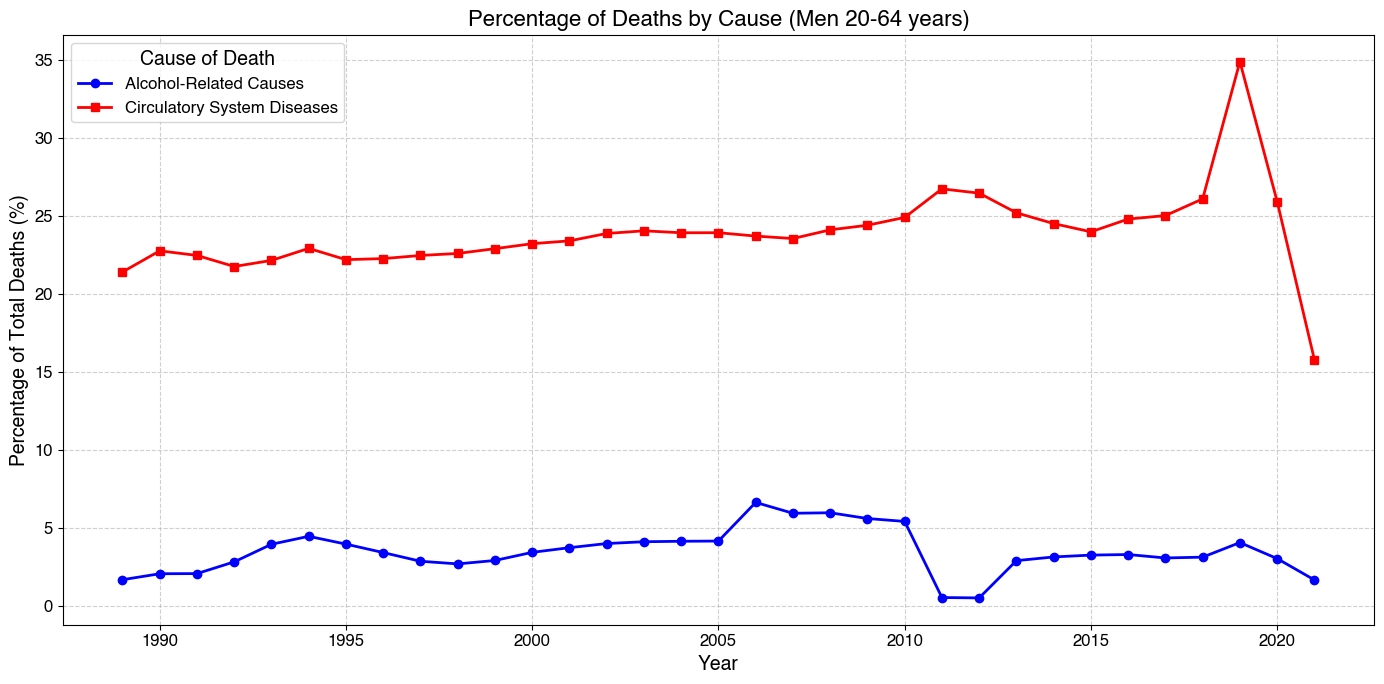

In [25]:
plt.figure(figsize=(14, 7))

# Plot percentage of deaths from alcohol-related causes
plt.plot(df_result['Year'], df_result['Pct_from_alcohol'], label='Alcohol-Related Causes', color='blue', linewidth=2, marker='o')

# Plot percentage of deaths from circulatory system diseases
plt.plot(df_result['Year'], df_result['Pct_from_circulatory'], label='Circulatory System Diseases', color='red', linewidth=2, marker='s')

# Add title and labels with improved styling
plt.title('Percentage of Deaths by Cause (Men 20-64 years)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=14)
plt.ylabel('Percentage of Total Deaths (%)', fontsize=14)

# Customize ticks
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Add grid with better visibility
plt.grid(True, linestyle='--', alpha=0.6)

# Add legend with improved styling
plt.legend(title='Cause of Death', fontsize=12, title_fontsize=14, loc='upper left')

# Adjust layout for better spacing
plt.tight_layout()

plt.show()

#### Mortality 1 year age group
We had to combine the dataset with population data so that we can correctly combine the death rates when grouping by regions

In [26]:
# Column name preparation
POP_PREFIX = 'PopDa'
DR_PREFIX = 'Dra'
death_rate_cols = [f"{DR_PREFIX}{age}" for age in age_considered]
pop_cols = [f"{POP_PREFIX}{age}" for age in age_considered]
columns = ['Year', 'Reg', 'Group', 'Sex'] + death_rate_cols + pop_cols
age_considered = range(18, 66)

In [27]:
# Load population data
df_pop1 = pd.read_csv('data/mortality_data/PopDa1989-2014.txt', dtype={'Year': int})
df_pop1 = df_pop1[df_pop1['Year'] < 2012]
df_pop2 = pd.read_csv('data/mortality_data/PopDa2012-2022.txt')
df_pop = pd.concat([df_pop1, df_pop2], ignore_index=True)

In [28]:
# Load mortality data
df1 = pd.read_csv('data/mortality_data/DRa1989-2014.txt')
df2 = pd.read_csv('data/mortality_data/DRa2012-2022.txt')
df1 = df1[df1['Year'] <  2012]
df = pd.concat([df1, df2], ignore_index=True)

# Column name preparation
POP_PREFIX = 'PopDa'
DR_PREFIX = 'Dra'
death_rate_cols = [f"{DR_PREFIX}{age}" for age in age_considered]
pop_cols = [f"{POP_PREFIX}{age}" for age in age_considered]
columns = ['Year', 'Reg', 'Group', 'Sex'] + death_rate_cols + pop_cols

# Filter for working age group 'T'
df_group_t = df[df['Group'] == 'T']
df_pop_group_t = df_pop[df_pop['Group'] == 'T']
# Merge mortality and population data
df_merged = pd.merge(
    df_group_t,
    df_pop_group_t,
    on=['Year', 'Reg', 'Group', 'Sex'],
    suffixes=('_mortality', '_population'),
    indicator=True  # this adds a column showing where each row came from
)
# print(df_merged['_merge'].value_counts())
# print(df_merged[df_merged['_merge'] != 'both'])

# Keep only relevant columns
df_merged = df_merged[['Year', 'Reg', 'Group', 'Sex'] + death_rate_cols + pop_cols]

# Convert death rate and population columns to numeric
df_merged[death_rate_cols] = df_merged[death_rate_cols].apply(pd.to_numeric, errors='coerce')
df_merged[pop_cols] = df_merged[pop_cols].apply(pd.to_numeric, errors='coerce')

# Compute weighted average death rates
def calculate_weighted_average(group):
    weighted_totals = []
    for dr_col, pop_col in zip(death_rate_cols, pop_cols):
        dr = group[dr_col]
        pop = group[pop_col]
        weighted_sum = (dr * pop).sum()
        total_pop = pop.sum()
        avg = weighted_sum / total_pop if total_pop > 0 else 0
        weighted_totals.append(avg)
    return pd.Series(weighted_totals, index=[f"TotalDra{age}" for age in age_considered])

# Apply the calculation grouped by Year and Sex
df_grouped = df_merged.groupby(['Year', 'Sex']).apply(calculate_weighted_average).reset_index()

# Display results
# Convert death rates from per 1,000,000 to per 1,000 population
death_rate_output_cols = [f"TotalDra{age}" for age in age_considered]
df_grouped[death_rate_output_cols] = df_grouped[death_rate_output_cols] / 1000

# Display results
df_grouped.head()

/var/folders/qh/8hb88qmn3hl16kq076vw9_0h0000gp/T/ipykernel_21509/849240774.py:48: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_grouped = df_merged.groupby(['Year', 'Sex']).apply(calculate_weighted_average).reset_index()


,Year,Sex,TotalDra18,TotalDra19,TotalDra20,TotalDra21,TotalDra22,TotalDra23,TotalDra24,TotalDra25,TotalDra26,TotalDra27,TotalDra28,TotalDra29,TotalDra30,TotalDra31,TotalDra32,TotalDra33,TotalDra34,TotalDra35,TotalDra36,TotalDra37,TotalDra38,TotalDra39,TotalDra40,TotalDra41,TotalDra42,TotalDra43,TotalDra44,TotalDra45,TotalDra46,TotalDra47,TotalDra48,TotalDra49,TotalDra50,TotalDra51,TotalDra52,TotalDra53,TotalDra54,TotalDra55,TotalDra56,TotalDra57,TotalDra58,TotalDra59,TotalDra60,TotalDra61,TotalDra62,TotalDra63,TotalDra64,TotalDra65
0,1989,B,1.317667,1.247656,1.401610,1.630033,1.743340,1.768095,1.808636,1.889352,1.942594,2.025587,2.140699,2.261165,2.352666,2.412627,2.497347,2.622271,2.834213,3.006358,3.135389,3.431729,3.492510,3.825985,4.361862,3.969552,5.087045,4.872000,5.527700,5.999583,5.700382,7.383050,7.142376,7.920831,8.882199,8.950349,9.874758,10.671513,11.885847,12.340542,13.431401,14.635755,15.481114,17.066908,18.485435,20.086683,20.901549,22.213548,23.179784,25.994456
1,1989,F,0.702082,0.730630,0.704955,0.695150,0.706278,0.711946,0.703949,0.776398,0.711973,0.781317,0.802973,0.857057,0.900090,0.947835,1.003109,1.074548,1.186527,1.291668,1.395752,1.449625,1.625655,1.808784,1.993916,1.964779,2.546815,2.375588,2.737058,3.075177,2.931722,3.702800,3.591797,4.013721,4.475092,4.606236,5.272736,5.863957,6.468801,6.924881,7.583350,8.362038,8.887403,9.908013,10.758009,11.908469,12.895001,14.802005,16.011907,18.654422
2,1989,M,1.899424,1.718877,2.053023,2.541964,2.751945,2.789633,2.874204,2.964112,3.134338,3.228266,3.442019,3.635476,3.776594,3.853558,3.969496,4.156582,4.477130,4.724069,4.882591,5.427069,5.374727,5.874865,6.783118,6.029365,7.716621,7.476990,8.445878,9.084801,8.722792,11.474352,11.105897,12.336339,13.935325,13.941382,15.187834,16.274147,18.270732,18.879190,20.720958,22.465979,23.844585,26.418519,28.817752,31.400890,32.819068,34.941015,37.333439,42.018011
3,1990,B,1.365061,1.359516,1.472757,1.619125,1.714224,1.768426,1.832315,1.889064,1.932983,2.007146,2.160898,2.251258,2.433123,2.535154,2.671323,2.820195,2.979215,3.205043,3.326195,3.500633,3.782378,4.005668,4.372678,4.972733,4.563696,5.727523,5.532551,6.474921,6.928881,6.374728,8.415643,8.274031,9.185546,9.963176,9.980085,11.019367,11.928333,13.250916,13.704325,14.925143,16.269907,17.415417,19.188353,20.341331,22.549566,23.351016,24.770779,25.818029
4,1990,F,0.731572,0.749406,0.749470,0.668268,0.711282,0.702535,0.736379,0.742655,0.673150,0.724611,0.852156,0.840324,0.949534,0.965209,1.015382,1.141821,1.191258,1.334319,1.396569,1.529222,1.679938,1.829877,1.984470,2.335696,2.171781,2.798457,2.753673,3.126954,3.369390,3.261463,4.264511,4.120304,4.717186,5.066169,5.122251,5.808935,6.415214,7.376413,7.618705,8.425198,9.239826,10.015995,11.045741,12.078329,13.685549,14.632487,16.372310,18.043416


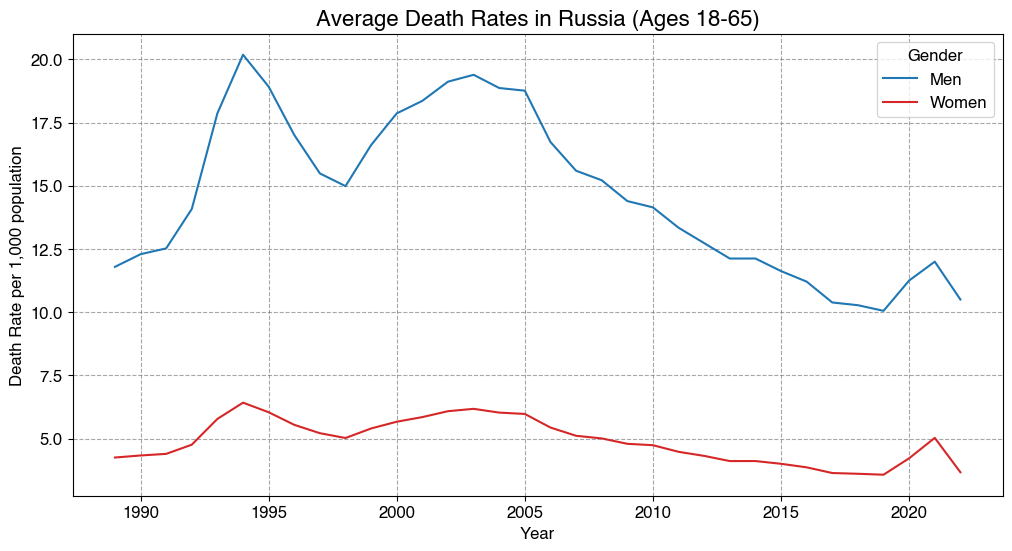

In [29]:
df_grouped['AverageDeathRate'] = df_grouped[[f"TotalDra{age}" for age in age_considered]].mean(axis=1)

pivot_df = df_grouped.pivot(index='Year', columns='Sex', values='AverageDeathRate')

plt.figure(figsize=(12, 6))

if 'M' in pivot_df.columns:
    plt.plot(pivot_df.index, pivot_df['M'], label='Men', color='tab:blue', linewidth=1.5)

if 'F' in pivot_df.columns:
    plt.plot(pivot_df.index, pivot_df['F'], label='Women', color='tab:red', linewidth=1.5)

# Add labels, title, and legend
plt.title('Average Death Rates in Russia (Ages 18-65)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontweight='bold')
plt.ylabel('Death Rate per 1,000 population')
plt.legend(loc='upper right', title='Gender')
plt.grid(True, linestyle='--', alpha=0.7, color='gray')

plt.show()

### Alcohol consumption per capita, WHO

#### Cleaining and preprocessing
The dataset was of good quality and we only had to map the column names to more useable names, as they were very cryptic (e.g. Dim1 was actually just the beverage type)

In [30]:
# Dataset already contains only Russia
df_alco_raw = pd.read_csv('data/consumption_by_beverage.csv')
column_mapping = {
    "Period": "Year",                # Year of the data
    "SpatialDimValueCode": "CountryCode",  # Country code
    "Dim1": "BeverageType",          # Type of beverage
    "FactValueNumeric": "Value"      # Value of alcohol consumption
}
df_alco = df_alco_raw[column_mapping.keys()].copy()
df_alco.rename(columns=column_mapping, inplace=True)

#### Stats

The dataset covers yeras from 1963 to 2020. It contains 4 main beverage types: beer, wine, spirits and other.

In [31]:
df_alco.head()

,Year,CountryCode,BeverageType,Value
0,2020,RUS,Other alcoholic beverages,0.00
1,2020,RUS,Wine,1.06
2,2020,RUS,Beer,3.06
3,2020,RUS,Spirits,3.17
4,2020,RUS,All types,7.30


In [32]:
# Years
df_alco['Year'].unique()

array([2020, 2019, 2018, 2017, 2016, 2015, 2014, 2013, 2012, 2011, 2010,
       2009, 2008, 2007, 2006, 2005, 2004, 2003, 2002, 2001, 2000, 1999,
       1998, 1997, 1996, 1995, 1994, 1993, 1992, 1991, 1990, 1989, 1988,
       1987, 1986, 1985, 1984, 1983, 1982, 1981, 1980, 1979, 1978, 1977,
       1976, 1975, 1974, 1973, 1972, 1971, 1970, 1969, 1968, 1967, 1966,
       1965, 1964, 1963])

In [33]:
# Get unique beverage types
df_alco['BeverageType'].unique()

array(['Other alcoholic beverages', 'Wine', 'Beer', 'Spirits',
       'All types'], dtype=object)

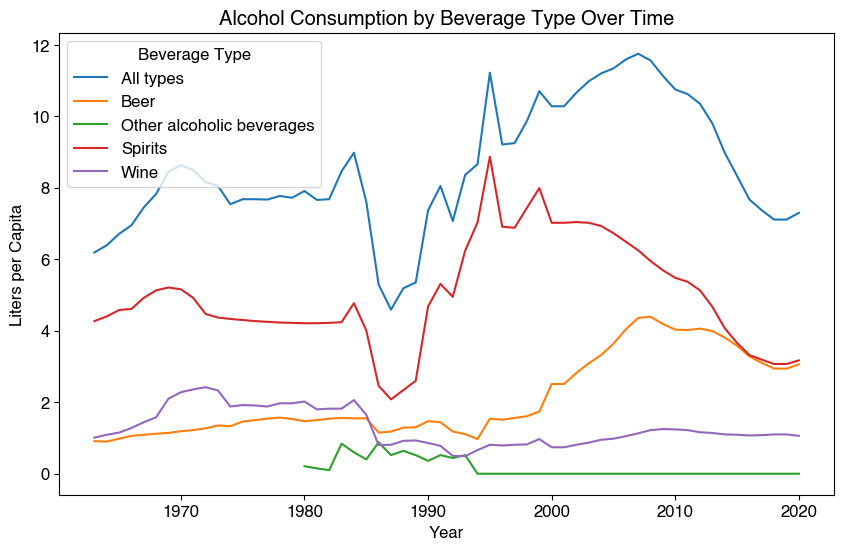

In [34]:
beverage_consumption = df_alco.groupby(['BeverageType', 'Year'])['Value'].sum().unstack('BeverageType')
beverage_consumption.plot(kind='line', title='Alcohol Consumption by Beverage Type Over Time', ylabel='Liters per Capita')
plt.legend(title='Beverage Type')
plt.show()

### Life expectancy dataset

#### Cleaining and preprocessing
This was already a cleaned and processed dataset so we did not have to do anything before the analysis

#### Stats


The dataset covers 290 countries or regions, it spans from 1950 to 2023. Russia life expectancy for men lower then the world average in recent years. Life expectancy for women much higher.

In [35]:
# Load the dataset
df_life_expectancy = pd.read_csv('data/life_expectancy/life-expectancy-of-women-vs-life-expectancy-of-men.csv')

df_life_expectancy.head()

,Entity,Code,Year,Life expectancy - Sex: female - Age: 0 - Variant: estimates,Life expectancy - Sex: male - Age: 0 - Variant: estimates,Population - Sex: all - Age: all - Variant: estimates,World regions according to OWID
0,Afghanistan,AFG,1950,28.834,27.547,7776133.0,NaN
1,Afghanistan,AFG,1951,29.275,27.971,7879295.0,NaN
2,Afghanistan,AFG,1952,29.714,28.394,7987737.0,NaN
3,Afghanistan,AFG,1953,30.164,28.822,8096656.0,NaN
4,Afghanistan,AFG,1954,30.396,29.079,8207910.0,NaN


In [36]:
print(f"Dataset contains {df_life_expectancy['Entity'].unique().size} countries or regions.")

Dataset contains 290 countries or regions.


In [37]:
df_life_expectancy['Year'].unique()

array([1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960,
       1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971,
       1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982,
       1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993,
       1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004,
       2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015,
       2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023])

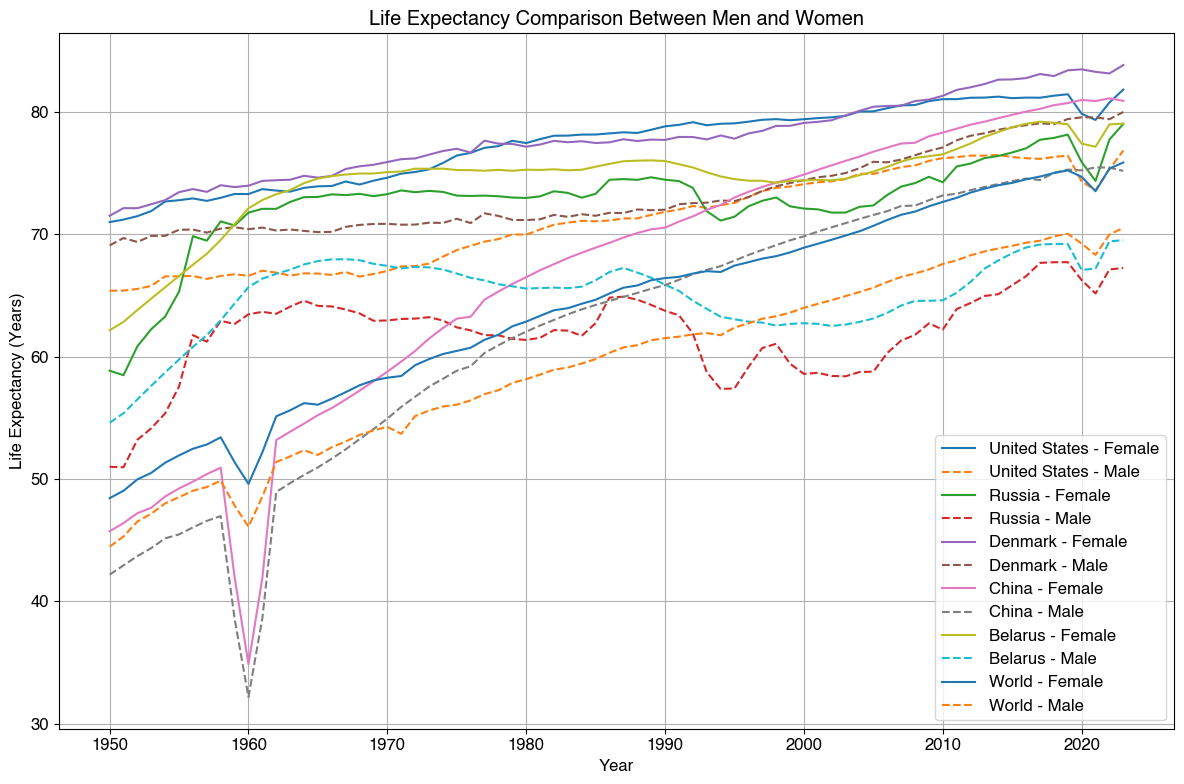

In [38]:
# Create a pivot table for easier plotting
# Define the selected countries
selected_countries = ['United States', 'Russia', 'Denmark', 'China', 'Belarus', 'World']
df_selected = df_life_expectancy[df_life_expectancy['Entity'].isin(selected_countries)]
pivot_life_expectancy = df_selected.pivot(index='Year', columns='Entity', values=[
    'Life expectancy - Sex: female - Age: 0 - Variant: estimates',
    'Life expectancy - Sex: male - Age: 0 - Variant: estimates'
])

# Plot life expectancy for men and women
plt.figure(figsize=(12, 8))
for country in selected_countries:
    plt.plot(
        pivot_life_expectancy.index,
        pivot_life_expectancy['Life expectancy - Sex: female - Age: 0 - Variant: estimates'][country],
        label=f'{country} - Female'
    )
    plt.plot(
        pivot_life_expectancy.index,
        pivot_life_expectancy['Life expectancy - Sex: male - Age: 0 - Variant: estimates'][country],
        label=f'{country} - Male',
        linestyle='--'
    )

plt.title('Life Expectancy Comparison Between Men and Women')
plt.xlabel('Year')
plt.ylabel('Life Expectancy (Years)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 3. Data Analysis
Describe your data analysis and explain what you've learned about the dataset.
If relevant, talk about your machine-learning.

Multiple datasets were loaded, including mortality, life expectancy, and alcohol consumption. Columns were renamed or mapped for clarity. Data was filtered for specific groups, as we were looking at the effects of alcohol. We focused on the working-age population (18–65) since drinking below 18 is illegal, and above 65, mortality naturally increases due to old age.

Mortality data was analyzed by age, gender, and cause of death. Additionally, we used the life expectancy data as it was already compiled by countries, allowing us to easily put the life expectancy in Russia in context with other countries. We were very surprised to see that the male life expectancy in Russia was below the world average and had been this way since the Soviet collapse.

Combining male mortality with alcohol consumption data confirmed the correlation between alcohol consumption and male mortality. It also provided information that this trend began after the collapse of the Soviet Union and the uncertain times that followed.


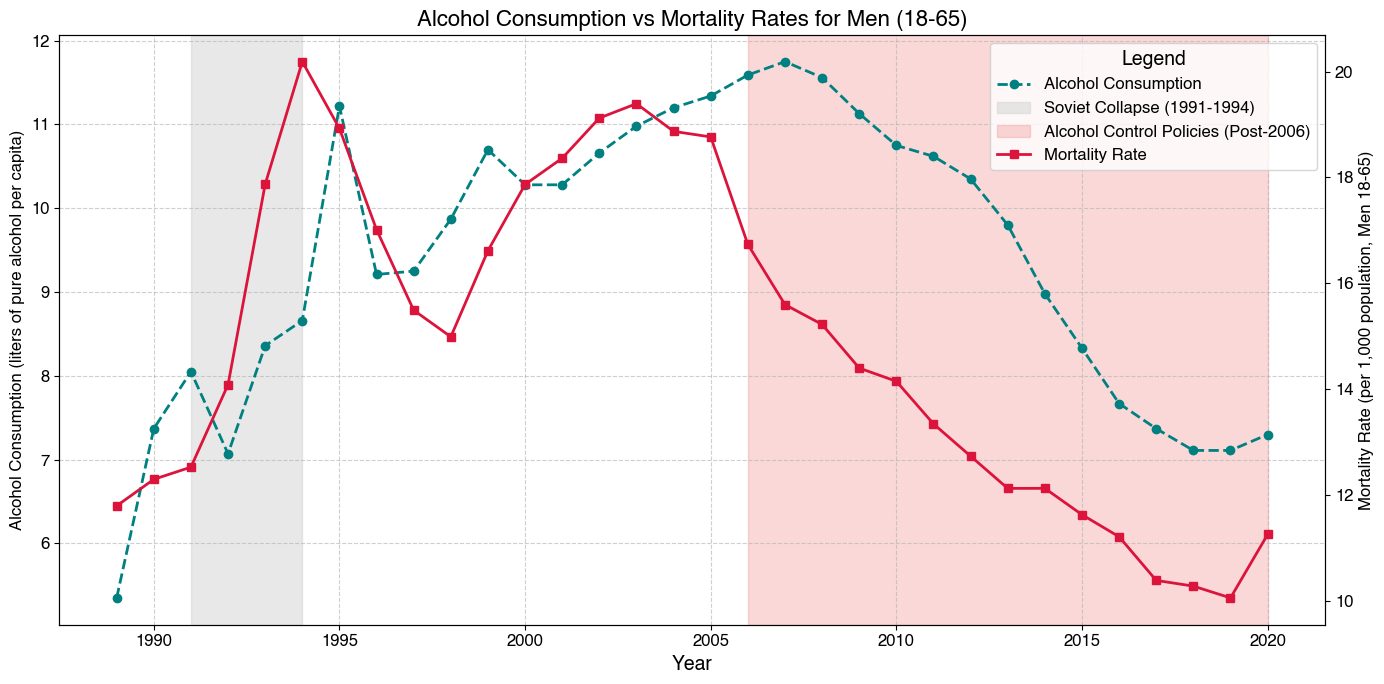

In [39]:
# Merge alcohol consumption data with mortality data
df_alco_men = df_alco[df_alco['BeverageType'] == 'All types'].copy()
df_alco_men = df_alco_men.groupby('Year')['Value'].mean().reset_index()
# pivot_df from mortality data
df_merged = pd.merge(df_alco_men, pivot_df[['M']].reset_index(), on='Year', how='inner')

# Rename columns for clarity
df_merged.rename(columns={'Value': 'AlcoholConsumption', 'M': 'MortalityRate'}, inplace=True)

# Plot alcohol consumption and mortality rates
fig, ax1 = plt.subplots(figsize=(14, 7))

# Plot alcohol consumption
ax1.set_xlabel('Year', fontsize=14, fontweight='bold')
ax1.set_ylabel('Alcohol Consumption (liters of pure alcohol per capita)', fontsize=12)
ax1.plot(df_merged['Year'], df_merged['AlcoholConsumption'], label='Alcohol Consumption', color='teal', linestyle='--', linewidth=2, marker='o')
ax1.tick_params(axis='y', labelsize=12)

# Create a second y-axis for mortality rates
ax2 = ax1.twinx()
ax2.set_ylabel('Mortality Rate (per 1,000 population, Men 18-65)', fontsize=12)
ax2.plot(df_merged['Year'], df_merged['MortalityRate'], label='Mortality Rate', color='crimson', linestyle='-', linewidth=2, marker='s')
ax2.tick_params(axis='y', labelsize=12)

# Add vertical lines for key events
ax1.axvspan(1991, 1994, color='lightgray', alpha=0.5, label='Soviet Collapse (1991-1994)')
ax1.axvspan(2006, max(df_merged['Year']), color='lightcoral', alpha=0.3, label='Alcohol Control Policies (Post-2006)')

# Add title and grid
plt.title('Alcohol Consumption vs Mortality Rates for Men (18-65)', fontsize=16, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.6)

# Add legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax2.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right', fontsize=12, title='Legend', title_fontsize=14)

# Adjust layout for better spacing
fig.tight_layout()

plt.show()


## 4. Genre. Which genre of data story did you use?
Which tools did you use from each of the 3 categories of Visual Narrative (Figure 7 in Segal and Heer). Why?


- Genre - Magazine.
- Feature distinction - in the life expectancy plots Russia is highlighted, while other countries have their opacity turned down

## 5. Visualizations.
Explain the visualizations you've chosen.
Why are they right for the story you want to tell?


### Mortality
We have chosen time series plots to display the change in mortality and the significant difference between men and women. Additionally, we included life expectancy time series plots to further emphasize the difference. Life expectancy plots are particularly effective for the average reader, as they can easily understand the meaning of a life expectancy of 65 years—compared to interpreting a statistic like 15 deaths per 1,000 population.

Finally, we have also used a time series to combine the mortality data for men and alcohol consumption, which clearly showed a correlation between alcohol consumption and male mortality. It was also clear to see the effects of the Soviet collapse on both mortality and alcohol consumption.

We were dealing mostly with yearly data of different types; this is why time series visualizations were the solution we chose to tell our story about mortality.

## 6. Discussion. Think critically about your creation
What went well?,
What is still missing? What could be improved?, Why?

### Mortality
The story conveyed with the mortality data and its conclusions nicely confirms the connections between alcohol consumption and mortality mentioned in the introduction. 

Maybe it's worth exploring the effects of alcohol consumption on women, as this was overlooked since male mortality is much higher. Additionally, maps and further exploration of mortality by looking at different regions and considering rural vs. urban areas could provide new insights, as this was not done in the current analysis. 
Further research could also be done to look into does the rising share of beer, which replaces vodka, had an impact in reducing the mortality.

## 7. Contributions. Who did what?
You should write (just briefly) which group member was the main responsible for which elements of the assignment. (I want you guys to understand every part of the assignment, but usually there is someone who took lead role on certain portions of the work. That's what you should explain).